# 03 — Evaluation

Test set results for all experiments: confusion matrices, noise robustness, and full comparison table.

To regenerate results, run from project root:
```bash
python evaluate.py --feature mel
python evaluate.py --feature mfcc
python evaluate.py --feature mel --no-augment
python evaluate.py --feature mel --no-dropout
python evaluate.py --feature mel --dataset ravdess
python evaluate.py --feature mel --dataset ravdess --pretrain-from models/mel_best_model.pt --lr 0.0003
```

In [1]:
import sys
sys.path.insert(0, '..')

import os
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

## Confusion Matrices

Each cell shows how often the model predicted class X when the true class was Y. The diagonal is correct predictions — everything off-diagonal is an error.

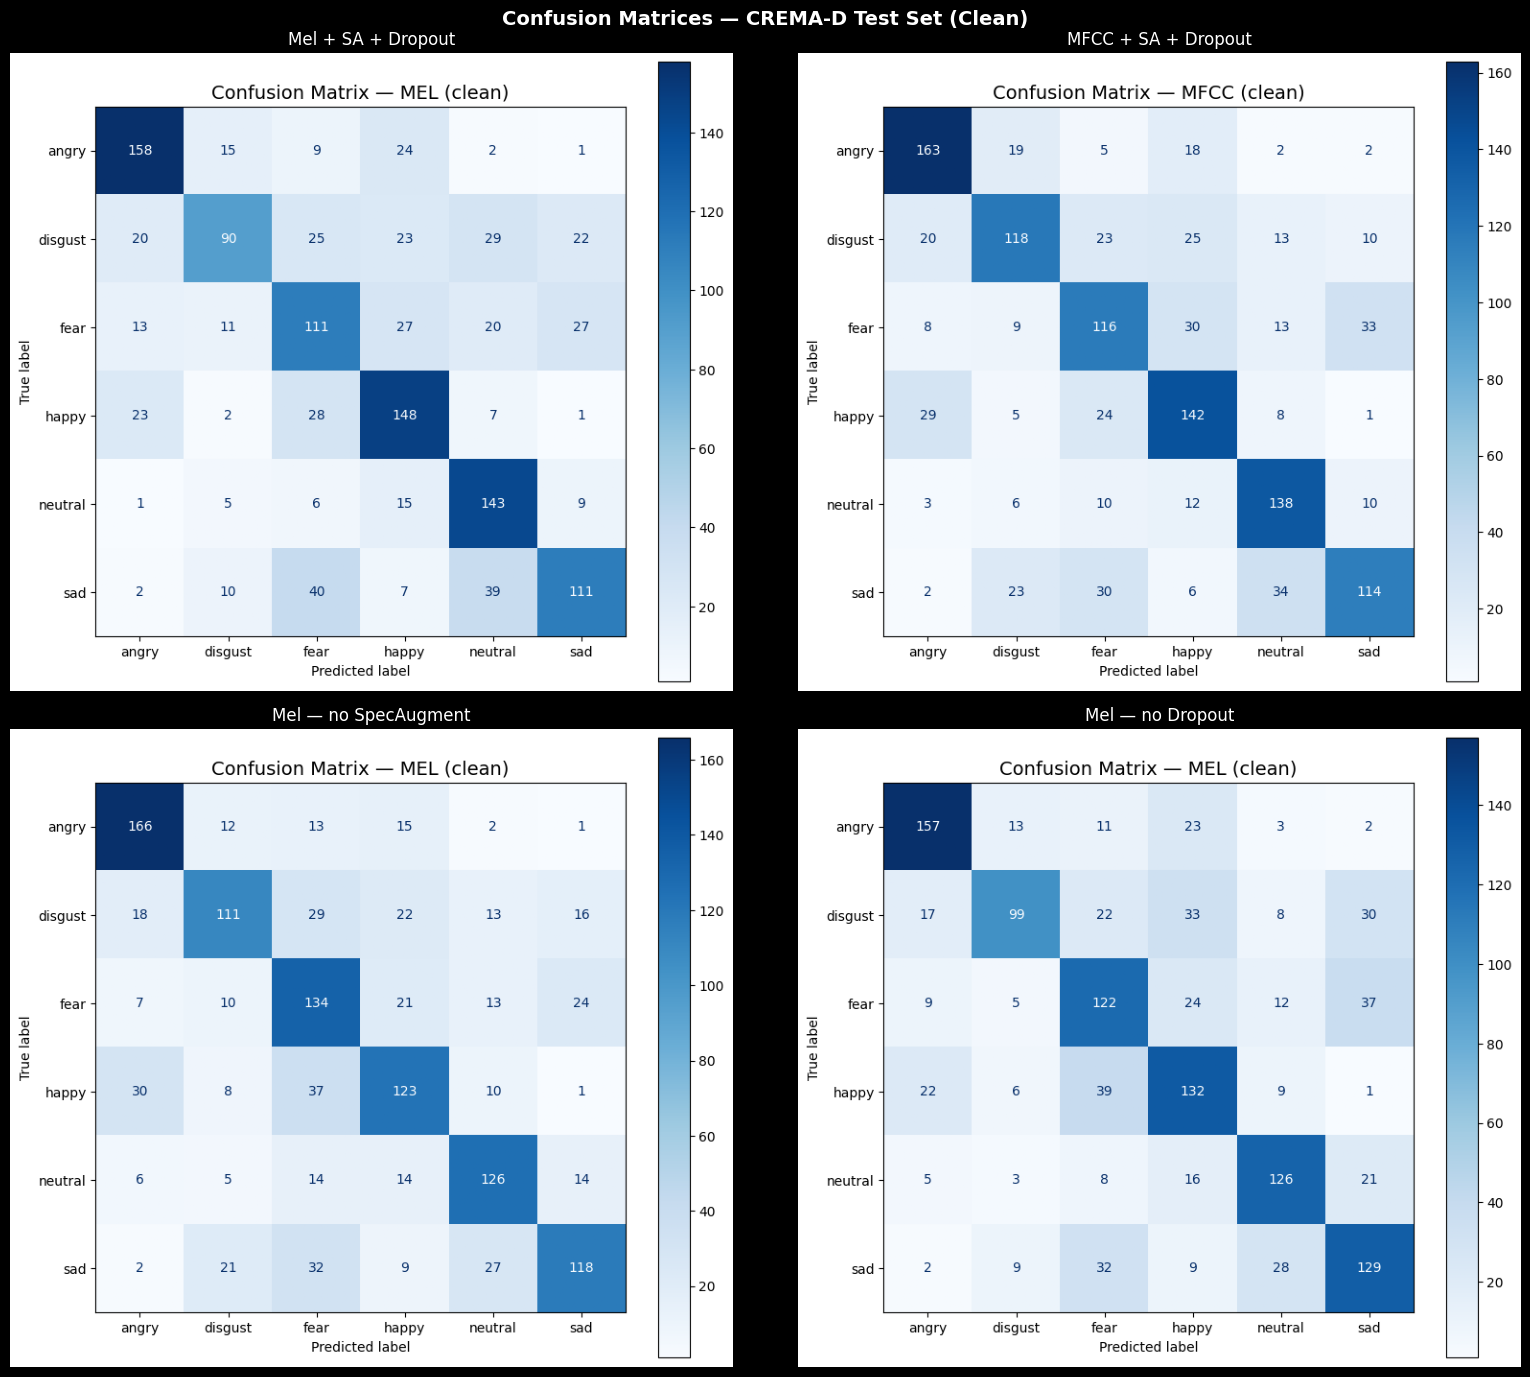

In [2]:
cm_paths = {
    'Mel + SA + Dropout':    '../results/mel/confusion_matrix.png',
    'MFCC + SA + Dropout':   '../results/mfcc/confusion_matrix.png',
    'Mel — no SpecAugment':  '../results/mel_noaug/confusion_matrix.png',
    'Mel — no Dropout':      '../results/mel_nodropout/confusion_matrix.png',
}

fig, axes = plt.subplots(2, 2, figsize=(16, 14))
axes = axes.flatten()
for ax, (title, path) in zip(axes, cm_paths.items()):
    if os.path.exists(path):
        ax.imshow(mpimg.imread(path))
        ax.set_title(title, fontsize=12)
    else:
        ax.text(0.5, 0.5, f'Not found:\n{path}', ha='center', va='center', transform=ax.transAxes)
    ax.axis('off')
plt.suptitle('Confusion Matrices — CREMA-D Test Set (Clean)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## Noise Robustness

F1-score under three conditions:
- **Clean** — original audio, no noise
- **SNR-20 dB** — moderate Gaussian noise
- **SNR-5 dB** — heavy Gaussian noise

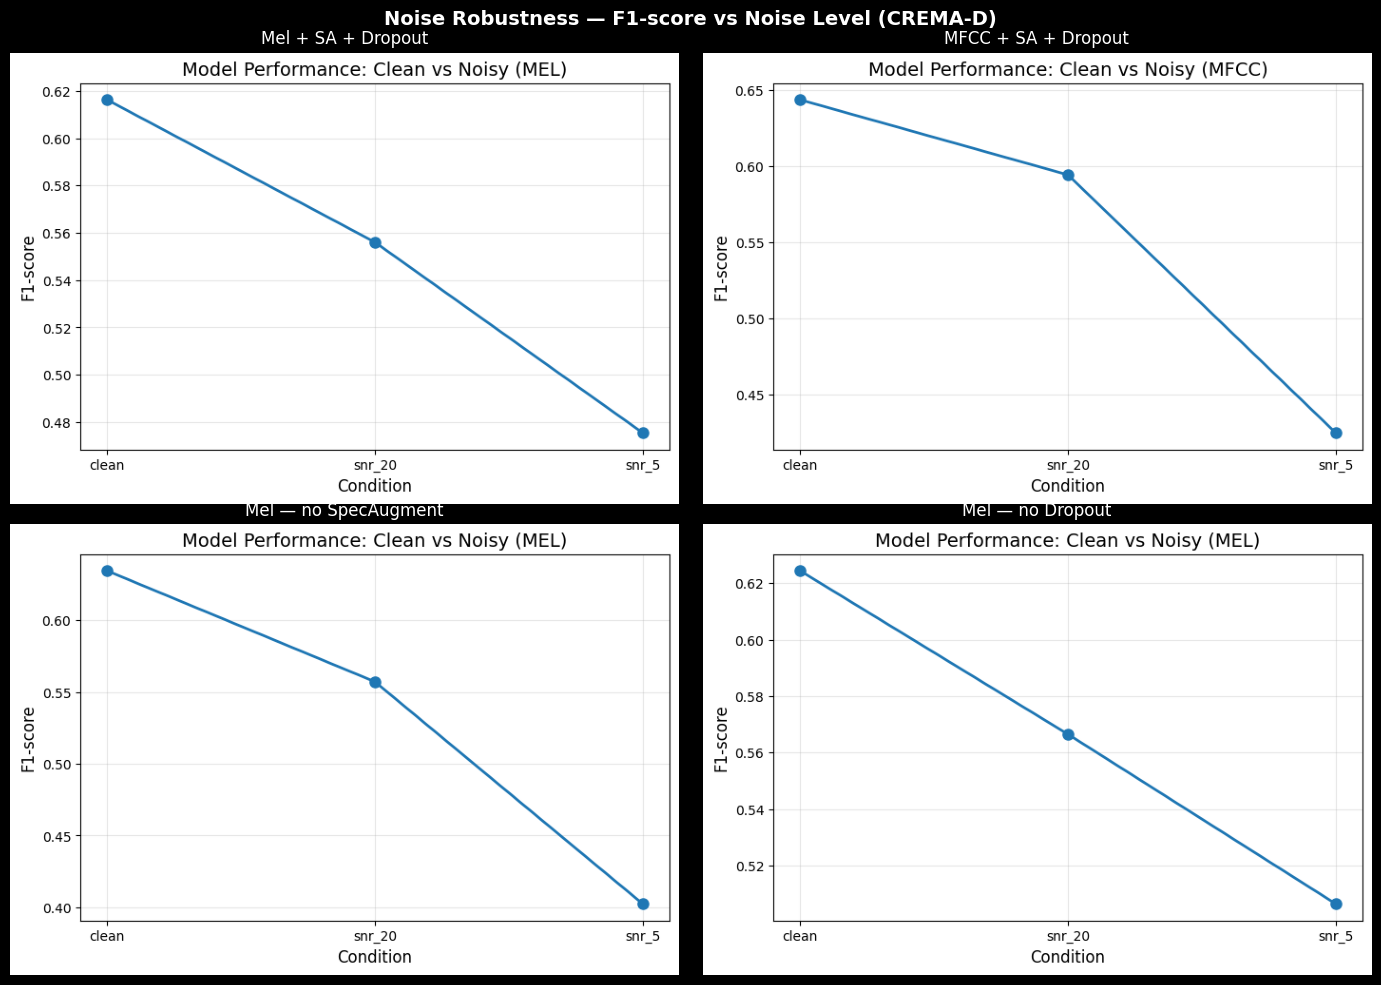

In [3]:
noise_paths = {
    'Mel + SA + Dropout':    '../results/mel/noise_robustness.png',
    'MFCC + SA + Dropout':   '../results/mfcc/noise_robustness.png',
    'Mel — no SpecAugment':  '../results/mel_noaug/noise_robustness.png',
    'Mel — no Dropout':      '../results/mel_nodropout/noise_robustness.png',
}

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()
for ax, (title, path) in zip(axes, noise_paths.items()):
    if os.path.exists(path):
        ax.imshow(mpimg.imread(path))
        ax.set_title(title, fontsize=12)
    else:
        ax.text(0.5, 0.5, f'Not found:\n{path}', ha='center', va='center', transform=ax.transAxes)
    ax.axis('off')
plt.suptitle('Noise Robustness — F1-score vs Noise Level (CREMA-D)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## Full Results Table (all experiments)

In [4]:
import pandas as pd

df = pd.read_csv('../results/comparison_table.csv')

# Readable labels for the experiment column
label_map = {
    'mel':                         'Mel + SA + Dropout (CREMA-D)',
    'mfcc':                        'MFCC + SA + Dropout (CREMA-D)',
    'mel_noaug':                   'Mel — no SpecAugment (CREMA-D)',
    'mel_nodropout':               'Mel — no Dropout (CREMA-D)',
    'ravdess_mel':                 'Mel from scratch (RAVDESS)',
    'ravdess_mel_lr0003_transfer': 'Mel transfer from CREMA-D (RAVDESS)',
}

df['Configuration'] = df['experiment'].map(label_map).fillna(df['experiment'])
df['Clean F1']      = (df['clean_f1'] * 100).round(2).astype(str) + '%'
df['SNR-20 dB F1']  = (df['snr20_f1'] * 100).round(2).astype(str) + '%'
df['SNR-5 dB F1']   = (df['snr5_f1']  * 100).round(2).astype(str) + '%'

display(df[['Configuration', 'Clean F1', 'SNR-20 dB F1', 'SNR-5 dB F1']].reset_index(drop=True))

,Configuration,Clean F1,SNR-20 dB F1,SNR-5 dB F1
0,Mel + SA + Dropout (CREMA-D),61.62%,55.6%,47.54%
1,MFCC + SA + Dropout (CREMA-D),64.36%,59.44%,42.51%
2,Mel — no SpecAugment (CREMA-D),63.45%,55.72%,40.24%
3,Mel — no Dropout (CREMA-D),62.44%,56.65%,50.64%
4,Mel from scratch (RAVDESS),39.3%,21.59%,14.25%
5,Mel transfer from CREMA-D (RAVDESS),52.68%,44.3%,37.16%


## RAVDESS — Confusion Matrices (Scratch vs. Transfer)

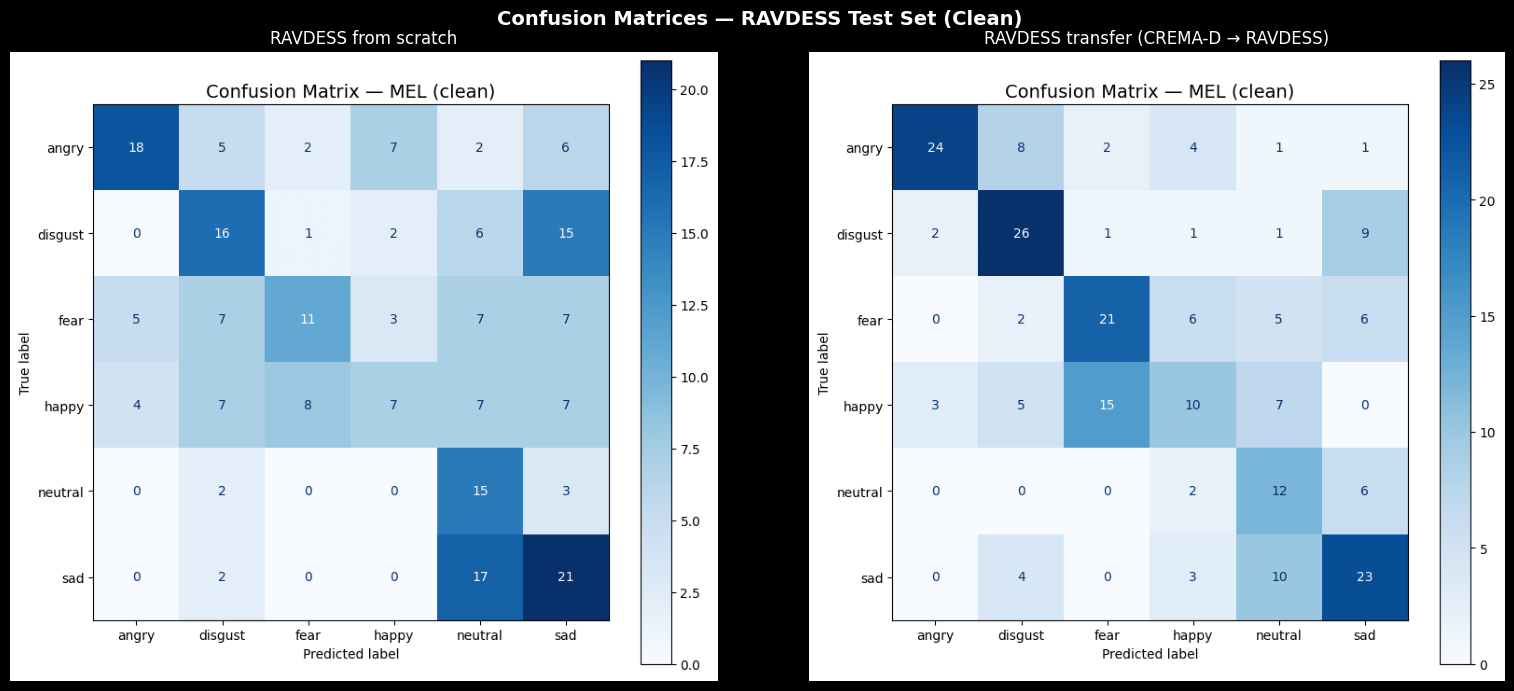

In [5]:
ravdess_cm = {
    'RAVDESS from scratch':          '../results/ravdess_mel/confusion_matrix.png',
    'RAVDESS transfer (CREMA-D → RAVDESS)': '../results/ravdess_mel_lr0003_transfer/confusion_matrix.png',
}

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
for ax, (title, path) in zip(axes, ravdess_cm.items()):
    if os.path.exists(path):
        ax.imshow(mpimg.imread(path))
        ax.set_title(title, fontsize=12)
    else:
        ax.text(0.5, 0.5, f'Not found:\n{path}', ha='center', va='center', transform=ax.transAxes)
    ax.axis('off')
plt.suptitle('Confusion Matrices — RAVDESS Test Set (Clean)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()